# L3. Finding the Right Memory

Half of a day's memory is what you saw, so photos join the notes: same shard, a second named vector. Find a photo by describing it, then narrow recall with a filter on category and price.

## 1. One shard, two named vectors

In [1]:
from qdrant_edge import EdgeShard, EdgeConfig, EdgeVectorParams, Distance
from helper import fresh_start

SHARD_DIR = fresh_start("./mem_shard")

config = EdgeConfig(
    vectors={
        "text": EdgeVectorParams(size=768, distance=Distance.Cosine),
        "image": EdgeVectorParams(size=512, distance=Distance.Cosine),
    }
)
shard = EdgeShard.create(SHARD_DIR, config)
print("Shard ready: text 768-d (Nomic), image 512-d (CLIP)")

Shard ready: text 768-d (Nomic), image 512-d (CLIP)


## 2. Store text notes

In [2]:
import json
from qdrant_edge import Point, UpdateOperation
from helper import embed_text

memories = json.load(open("../data/memories.json"))
notes = [m for m in memories if m["source_type"] == "text"]

vectors = embed_text([m["note"] for m in notes])
shard.update(UpdateOperation.upsert_points([
    Point(id=m["id"], vector={"text": vector}, payload=m)
    for m, vector in zip(notes, vectors)
]))
print("Stored", len(notes), "text notes")

Stored 20 text notes


## 3. Store a photo library

A bank of everyday photos, embedded with CLIP into the `image` vector.

In [3]:
from pathlib import Path
from fastembed import ImageEmbedding

bank = sorted(Path("../data/bank").glob("*.jpg"))

clip_vision = ImageEmbedding("Qdrant/clip-ViT-B-32-vision")
vectors = [
    v.tolist() for v in
    clip_vision.embed([str(p) for p in bank])
]
shard.update(UpdateOperation.upsert_points([
    Point(id=1000 + i, vector={"image": vector},
          payload={"file": p.name, "source_type": "photo"})
    for i, (p, vector) in enumerate(zip(bank, vectors))
]))
shard.optimize()
print("Stored", len(bank), "photos as",
      len(vectors[0]), "d CLIP image vectors.",
      "Total:", shard.info().points_count, "memories")

Stored 165 photos as 512 d CLIP image vectors. Total: 185 memories


## 4. Find a photo by describing it

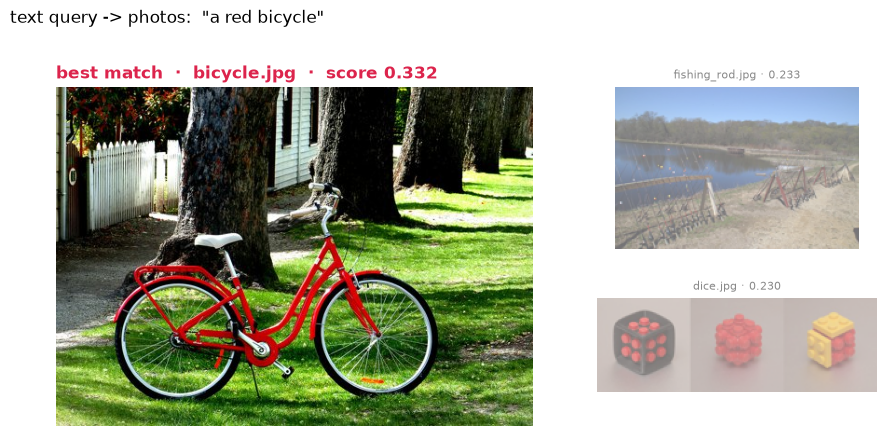

In [4]:
from qdrant_edge import Query, QueryRequest
from helper import embed_query_clip, show_photo_results

# Type any description and re-run. Try: "a slice of pizza",
# "a cute puppy dog", "a sunflower", "a sailboat on water",
# "a butterfly", "a cup of espresso". A photo that isn't in the
# bank still comes back as the nearest match, at a lower score.
my_description = "a red bicycle"

photo_hits = shard.query(
    QueryRequest(
        query=Query.Nearest(embed_query_clip(my_description), using="image"),
        limit=3,
        with_payload=True,
    )
)
show_photo_results(photo_hits, "../data/bank", my_description)

## 5. Recall with a filter

In [5]:
from qdrant_edge import PayloadSchemaType

for field, kind in [
    ("category", PayloadSchemaType.Keyword),
    ("price", PayloadSchemaType.Float),
]:
    shard.update(UpdateOperation.create_field_index(field, kind))
shard.optimize()
print("Indexed category and price")

Indexed category and price


In [6]:
from qdrant_edge import Filter, FieldCondition, MatchValue, RangeFloat
from helper import embed_query, before_after


def search(query_vector, query_filter=None, limit=4):
    hits = shard.query(
        QueryRequest(
            query=Query.Nearest(query_vector, using="text"),
            filter=query_filter,
            limit=limit,
            with_payload=True,
        )
    )
    rows = []
    for h in hits:
        p = h.payload
        price = f"${p['price']:.0f}" if "price" in p else "no price"
        text = p.get("note") or p["transcript"]
        rows.append(f"{p['category']:>8} · {price:>8}   {text[:52]}")
    return rows


query = "somewhere to eat"
query_vector = embed_query(query)
for row in search(query_vector):
    print(row)

    food · no price   Great little coffee place on 5th with outdoor seatin
    work · no price   Found a quiet cafe with good wifi to work from near 
    food · no price   Try the new ramen place downtown, everyone raves abo
    food ·       $3   Coffee run to the espresso bar near the office


In [7]:
cheap_food = Filter(
    must=[
        FieldCondition(key="category", match=MatchValue(value="food")),
        FieldCondition(key="price", range=RangeFloat(lt=15)),
    ]
)
before_after(query,
             "Similarity only", search(query_vector),
             "+ food under $15", search(query_vector, cheap_food))

query: "somewhere to eat"
✗ dropped by the filter · ✓ passed the filter

Similarity only:
  ✗     food · no price   Great little coffee place on 5th with outdoor seatin
  ✗     work · no price   Found a quiet cafe with good wifi to work from near 
  ✗     food · no price   Try the new ramen place downtown, everyone raves abo
        food ·       $3   Coffee run to the espresso bar near the office

+ food under $15:
  ✓     food ·       $3   Coffee run to the espresso bar near the office
  ✓     food ·       $4   New bakery on the corner does an amazing morning cro
